### Student Information
Name: 吳柏逸

Student ID: 114062553

GitHub ID: Ubereats9481

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas.
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__.

### Second Phase Submission

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__.

# Phase 1

In [214]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn plotly wordcloud


[notice] A new release of pip available: 22.3 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [215]:
### Begin Assignment Here
# Python version: 3.13.7
import pandas as pd
import helpers.data_mining_helpers as dmh
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preparation

In [216]:
data = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')
data.head()

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0


In [217]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          847 non-null    object 
 1   datetime      847 non-null    object 
 2   post_id       847 non-null    object 
 3   subreddit     847 non-null    object 
 4   title         847 non-null    object 
 5   author        847 non-null    object 
 6   url           847 non-null    object 
 7   upvotes       847 non-null    int64  
 8   downvotes     64 non-null     float64
 9   upvote_ratio  64 non-null     float64
 10  text          847 non-null    object 
 11  subjectivity  847 non-null    float64
 12  polarity      847 non-null    float64
 13  sentiment     847 non-null    float64
 14  entities      847 non-null    object 
 15  label         847 non-null    float64
dtypes: float64(6), int64(1), object(9)
memory usage: 106.0+ KB


In [218]:
# Exercise 1:
# print the first 3 examples
for i in range(3):
    print(f"example {i}")
    print("\n".join(data['text'][i].split("\n")))

example 0
Calls on retards
example 1
Stunt as in like why did they even make a big deal about starting it in the first place? No company should ever talk about politics ever.
example 2
Seeing lots of red in the ticker.


### Data Transformation & Data Mining using Pandas

In [219]:
# Exercise 2:
print(data.label[0:26:5])
print("----------------")

print([sum(data["label"] == i) for i in range(-1, 2)])  # check how many documents in each category
print("----------------")

print(data.at[0, 'text'])
print("----------------")

print(data.loc[data.index[[0, 10, 20]], ['text', 'label']])
print("----------------")

print(data.sample(3))
print("----------------")

0    -1.0
5     0.0
10    0.0
15    0.0
20   -1.0
25   -1.0
Name: label, dtype: float64
----------------
[315, 423, 109]
----------------
Calls on retards
----------------
                                            text  label
0                               Calls on retards   -1.0
10  It's a copy/paste from a Bloomberg terminal.    0.0
20           Nooo dont go down its smug bull day   -1.0
----------------
        type             datetime  post_id         subreddit  \
358  comment  2025-04-11 14:06:09  mmkctpx       StockMarket   
711  comment  2021-09-29 15:00:37  heqa1tv  stockstobuytoday   
344  comment  2025-04-11 15:16:54  mmkr0ld            stocks   

                                                 title          author  \
358  Trump is surrounded by a bunch of idiots, he s...  Brokenandburnt   
711                         Technical Analysis Thread.         saasfin   
344  BREAKING: China raises tariffs on U.S. goods t...        peatoast   

                                 

In [220]:
# Exercise 3:
data[data.label == 1][::10][:5]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
78,comment,2025-04-11 15:11:59,mmkq0pj,StockMarket,$ U.S. dollar value (crashing),AdQuick8612,https://i.redd.it/atvlo83gk4ue1.jpeg,1,NaN,NaN,I think it’s gonna work itself out. I bought t...,0.133333,-0.133333,-1.0,"['trading', 'app', 'gloom', 'doom', 'gon']",1.0
168,comment,2025-04-11 13:09:51,mmk2ho9,stocks,r/Stocks Daily Discussion & Fundamentals Frida...,mazzaschi,https://www.reddit.com/r/stocks/comments/1jwlr...,1,NaN,NaN,The obvious can also be refreshing from CNBC: ...,0.750000,0.250000,1.0,"['bond', 'U.S', 'dollar', '’', 'Fed', 'CNBC', ...",1.0
219,comment,2023-08-12 2:20:58,jvtj2dl,stockstobuytoday,APLS stocks,muffins95,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,Same. Back to break even after that last rip b...,0.300000,0.144444,1.0,"['rip', 'Same', 'Back', '%', 'thing']",1.0
319,comment,2021-02-01 14:44:17,gllpzay,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",inuvash255,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Etrade has a feed of news articles about how r...,0.000000,0.000000,0.0,"['news', 'actual-reddit', 'reddit', 'GME', 'Et...",1.0


In [221]:
data.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0,0,0,783,783,0,0,0,0,0,0


In [222]:
# Exercise 4:
data.isnull().apply(lambda x: dmh.check_missing_values(x), axis=1)

0      (The amoung of missing records is: , 2)
1      (The amoung of missing records is: , 2)
2      (The amoung of missing records is: , 2)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 2)
                        ...                   
842    (The amoung of missing records is: , 2)
843    (The amoung of missing records is: , 2)
844    (The amoung of missing records is: , 0)
845    (The amoung of missing records is: , 2)
846    (The amoung of missing records is: , 2)
Length: 847, dtype: object

In [223]:
print(data.duplicated().sum())  # no duplicates

0


### Data Preprocessing

In [224]:
data_sample = data.sample(n=300, random_state=42)

label
 0.0    423
-1.0    315
 1.0    109
Name: count, dtype: int64


<Axes: title={'center': 'Label distribution'}, xlabel='label'>

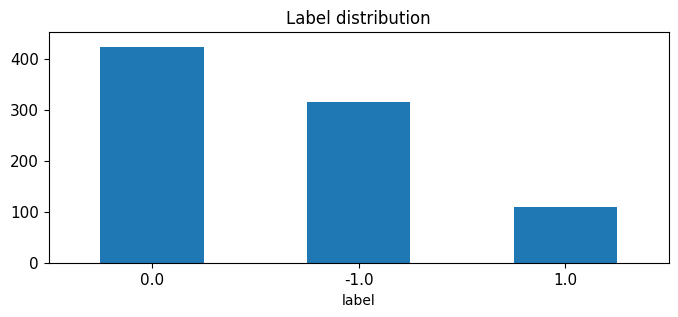

In [225]:
# Exercise 7:
print(data['label'].value_counts())
data.label.value_counts().plot(kind = 'bar',
                                    title = 'Label distribution',
                                    ylim = [0, data.label.value_counts().max() + 30],
                                    rot = 0, fontsize = 11, figsize = (8,3))

<Axes: title={'center': 'Label distribution'}, xlabel='label'>

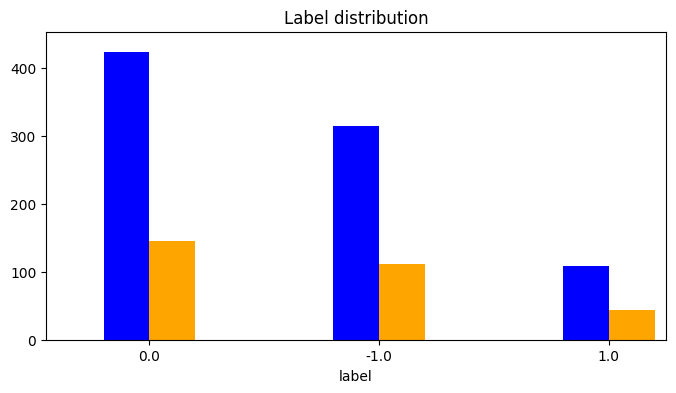

In [226]:
# Exercise 8:
data_sample.label.value_counts().plot(kind = 'bar', width=0.2,
                                           title = 'Label distribution',
                                           ylim = [0, data.label.value_counts().max()+30],
                                           rot = 0, fontsize = 10, figsize = (8,4), color="orange", position=0)
data.label.value_counts().plot(kind = 'bar', width=0.2,
                                    title = 'Label distribution',
                                    ylim = [0, data.label.value_counts().max()+30],
                                    rot = 0, fontsize = 10, figsize = (8,4), color="blue", position=1)

#### Feature Creation

In [227]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ubereats81/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/ubereats81/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [228]:
data['unigrams'] = data['text'].apply(lambda x: dmh.tokenize_text(x))

In [229]:
data[0:4]["unigrams"]

0                                 [Calls, on, retards]
1    [Stunt, as, in, like, why, did, they, even, ma...
2          [Seeing, lots, of, red, in, the, ticker, .]
3    [Vision, Marine, Technologies, Inc., is, rewri...
Name: unigrams, dtype: object

#### Feature Subset Selection

In [230]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
data_counts = count_vect.fit_transform(data.text) #learn the vocabulary and return document-term matrix
print(data_counts[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 4346)>
  Coords	Values
  (0, 692)	1
  (0, 2706)	1
  (0, 3248)	1


In [231]:
print(count_vect.get_feature_names_out()[692])
print(count_vect.get_feature_names_out()[2706])
print(count_vect.get_feature_names_out()[3248])


calls
on
retards


In [232]:
# Exercise 9:
analyze = count_vect.build_analyzer()
analyze(data.text[0])

['calls', 'on', 'retards']

In [233]:
data_counts[0:30, 0:20].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

In [234]:
# Exercise 10:
print(data["text"][3])  # use index n to find the token "116"
n = np.where(data_counts[3, 0:20].toarray() == 3)[-1][-1]  # find the index of 3
count_vect.get_feature_names_out()[n]

Vision Marine Technologies Inc. is rewriting the watercraft rulebook. Their collaboration with Shaun Torrente has achieved the unthinkable – a blazing 116 mph on water! This isn't just about speed; it's about propelling electric boating into a new era. Their cutting-edge technology, combined with Torrente's skill, is making waves that'll ripple for generations.

**Highlight Main Points**

* Vision Marine Technologies Inc. achieves a record-breaking 116 mph speed on water with Shaun Torrente.
* The feat highlights the power of electric boating and pushes the limits of innovation.
* Partners like Octillion Power Systems and Danfoss Editron contribute to this groundbreaking achievement.

**TLDR**

Hold onto your seats – Vision Marine Technologies Inc. and Shaun Torrente have shattered the water-speed record at an astonishing 116 mph!  This isn't just about speed; it's about pioneering electric boating and innovation. The collaboration of technology, skill, and passion is creating ripples 

'116'

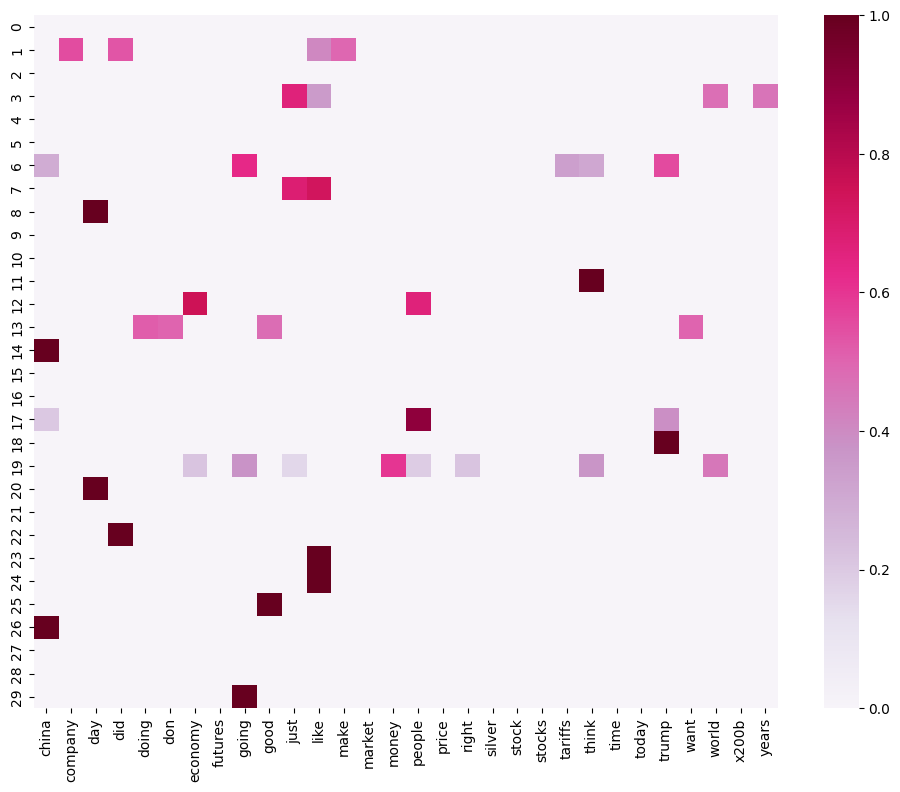

In [235]:
# Exercise 11:
from sklearn.feature_extraction.text import TfidfVectorizer

# Calculate TF-IDF matrix (try to find important words)
# 30 most important words, remove english stop words (e.g., is, the, a, ...)
vectorizer = TfidfVectorizer(max_features=30, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(data.text)

# show 0 ~ 29 documents and their tf-idf values for each term
terms = vectorizer.get_feature_names_out()
df_todraw = pd.DataFrame(tfidf_matrix[:30, :].toarray(), columns=terms)

plt.subplots(figsize=(12, 9))
ax = sns.heatmap(df_todraw,
                 cmap="PuRd",
                 vmin=0, vmax=1, annot=False)

# Discussion: Reddit posts are so short and sparse that even the most commonly used words might not appear in most posts.

In [236]:
term_frequencies = []
for j in range(0,data_counts.shape[1]):
    term_frequencies.append(sum(data_counts[:,j].toarray()))
term_frequencies = np.asarray(data_counts.sum(axis=0))[0]

In [237]:
# Exercise 12:
import plotly.express as px

fig = px.bar(
    x=count_vect.get_feature_names_out()[:300],
    y=term_frequencies[:300],
    labels={'x': 'Term', 'y': 'Frequency'},
)
fig.show()

In [238]:
# Exercise 13 & 14 (Two exercises' code are the same):
# calculate term frequencies for all terms
all_terms = count_vect.get_feature_names_out()
df_freq = pd.DataFrame({
    'Term': all_terms,
    'Frequency': term_frequencies
})
# choose top 100 terms
df_sorted = df_freq.sort_values(by='Frequency', ascending=False).head(100)

fig = px.bar(
    data_frame=df_sorted,
    x='Term',
    y='Frequency',
    labels={'Term': 'Term', 'Frequency': 'Frequency'},
)

fig.show()

In [239]:
# Exercise 15:
import math
term_frequencies_log = [math.log(i) for i in term_frequencies]
# calculate term frequencies for all terms
all_terms = count_vect.get_feature_names_out()
df_freq = pd.DataFrame({
    'Term': all_terms,
    'Frequency': term_frequencies_log
})
# choose top 100 terms
df_sorted = df_freq.sort_values(by='Frequency', ascending=False).head(100)

fig = px.bar(
    data_frame=df_sorted,
    x='Term',
    y='Frequency',
    labels={'Term': 'Term', 'Frequency': 'Frequency'},
)

fig.show()

### Generate meaningful new data visualizations.

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ubereats81/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


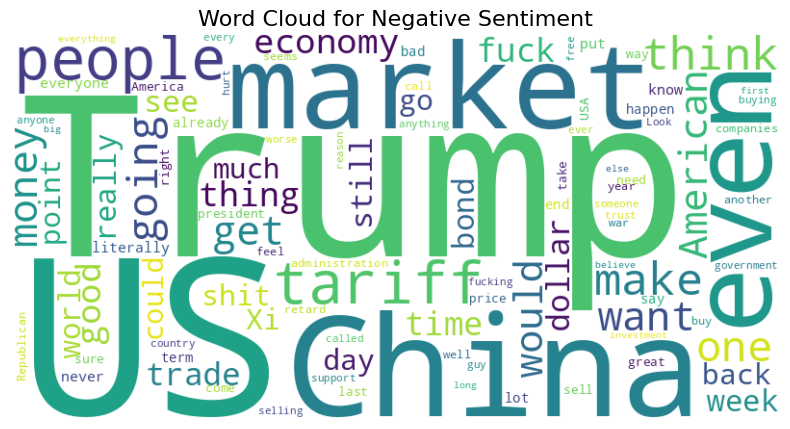

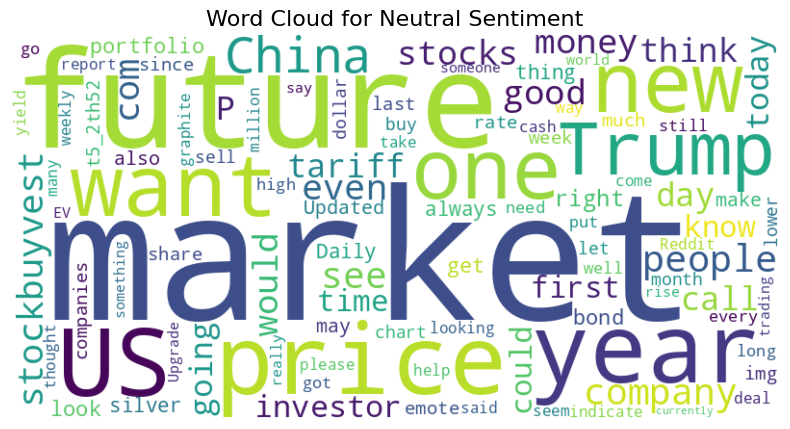

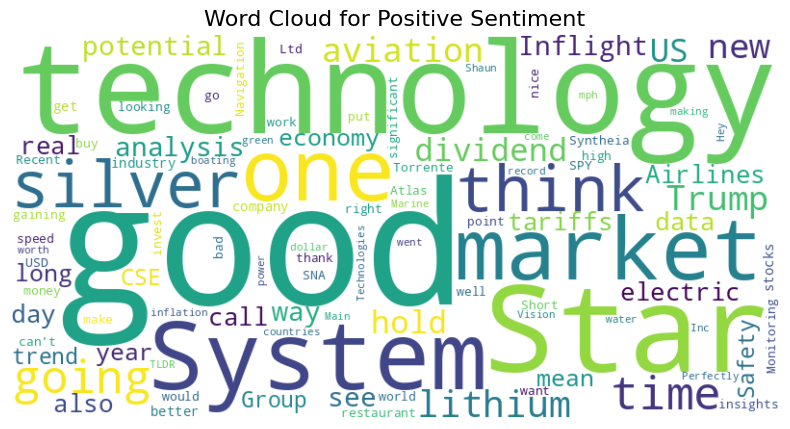

In [240]:
# Visualization 1: Wordcloud for each label (Ref: NLP course)
from wordcloud import WordCloud
from nltk.corpus import stopwords

# Get English stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Add custom stopwords specific to Reddit/stock discussions
custom_stopwords = {'stock', 'like', 'U', 'x200B'}
stop_words.update(custom_stopwords)

labels = {-1: "Negative", 0: "Neutral", 1: "Positive"}
for label in labels.keys():
    text = " ".join(data[data.label == label].text)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_words,  # Remove stopwords
        max_words=100,
        collocations=False,
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {labels[label]} Sentiment', fontsize=16)
    plt.axis('off')
    plt.show()

* We can see that for negative posts, "China", "Trump", "US" are the most common words, it is possible that these words have appeared significantly in negative posts due to the market volatility caused by the US-China confrontation and Trump's various policies in recent years.
* For neutral posts, "market", "price", "future" are the most common words, which are just common words in posts on the stock subreddit.
* For positive posts, "good", "technology", "star" are the most common words, in addition to general positive words, there are also some popular field words in recent years.

In [241]:
# Visualization 2: Boxplot of upvotes by sentiment category

# Remove outliers for better visualization
quantile_99 = data['upvotes'].quantile(0.99)
# Because over 50% of posts have 1 upvote, we filter out those with 1 or fewer upvotes
data_filtered = data[(data['upvotes'] > 1) & (data['upvotes'] < quantile_99)]

data_viz = data_filtered.copy()
data_viz['Sentiment'] = data_viz['label'].map({-1: 'Negative', 0: 'Neutral', 1: 'Positive'})
# Use log scale for upvotes to reduce skewness
data_viz['upvotes'] = [math.log(i) for i in data_viz['upvotes']]

# Draw boxplot
fig = px.box(data_viz,
             x='Sentiment',
             y='upvotes',
             color='Sentiment',
             title='Distribution of Upvotes by Sentiment (Log Scale)',
             labels={'upvotes': 'Number of Upvotes', 'Sentiment': 'Sentiment Label'},
             color_discrete_map={'Negative': '#ff6b6b', 'Neutral': '#95a5a6', 'Positive': '#51cf66'})
fig.show()

# Print summary statistics
print("----------------------------------------------------------------")
print("Upvotes Summary Statistics by Sentiment (Log Scale):")
print(data_viz.groupby('label')['upvotes'].describe())

----------------------------------------------------------------
Upvotes Summary Statistics by Sentiment (Log Scale):
       count      mean       std       min       25%       50%       75%  \
label                                                                      
-1.0   146.0  1.841578  1.010038  0.693147  0.693147  1.791759  2.564949   
 0.0   163.0  1.695867  0.998683  0.693147  0.693147  1.386294  2.397895   
 1.0    47.0  1.813178  1.093878  0.693147  0.693147  1.386294  2.484907   

            max  
label            
-1.0   4.406719  
 0.0   4.382027  
 1.0   4.007333  


In the raw data, I found that over half of the upvotes were 1, making it difficult to discern the overall trend. Therefore, I applied some filtering to this area.
Based on the boxplot, I observed that negative posts often had more upvotes than positive and neutral posts. This suggests that negative posts in the data are more likely to evoke user engagement.

# Phase 2

###  Finding frequent patterns

In [242]:
### Begin Assignment Here
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

categories = data['label'].unique()
category_dfs = {}

for category in categories:
    category_dfs[category] = data[data['label'] == category].copy()

def create_term_document_df(df):
    count_vect = CountVectorizer()
    X_counts = count_vect.fit_transform(df['text'])
    
    words = count_vect.get_feature_names_out()
    term_document_df = pd.DataFrame(X_counts.toarray(), columns=words)
    
    return term_document_df

# Create term-document frequency DataFrames for each category
filt_term_document_dfs = {}
for category in categories:
    filt_term_document_dfs[category] = create_term_document_df(category_dfs[category])

In [243]:
category_number=2 #You can change it from 0 to 2
print(f"Filtered Term-Document Frequency DataFrame for Category {categories[category_number]}:")
filt_term_document_dfs[categories[category_number]]

Filtered Term-Document Frequency DataFrame for Category 1.0:


,06,10,100,116,12,153,1728,18,1981,1992,...,year,years,yelling,yes,yesterday,yields,yikes,you,your,zero
0,0,0,0,3,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
105,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
106,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
107,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


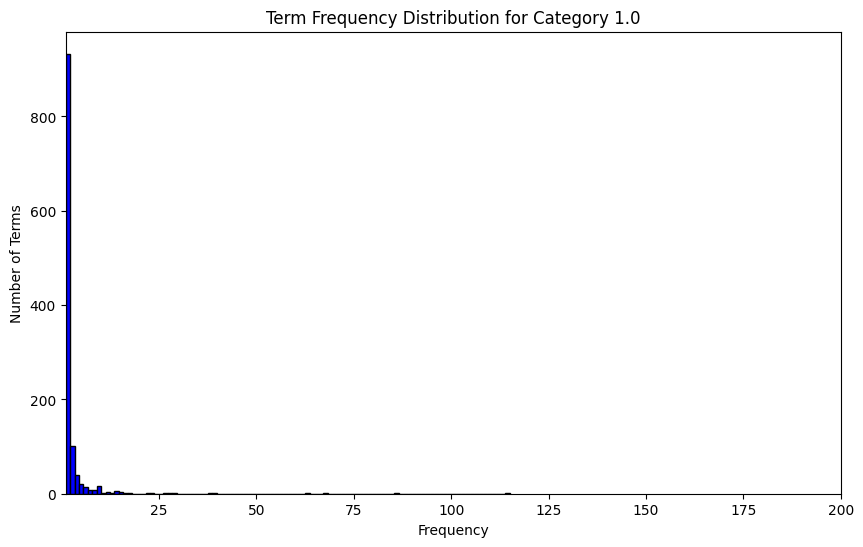

In [244]:
# Sum over all documents to get total frequency for each word
category_number=2 #You can change it from 0 to 2
word_counts = filt_term_document_dfs[categories[category_number]].sum(axis=0).to_numpy()
 
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=100, color='blue', edgecolor='black') # adjusted bins to 100 (because of smaller vocabularies)
plt.title(f'Term Frequency Distribution for Category {categories[category_number]}')
plt.xlabel('Frequency')
plt.ylabel('Number of Terms')
plt.xlim(1, 200)
plt.show()

In [245]:
category_number=2 #You can change it from 0 to 2
word_counts = filt_term_document_dfs[categories[category_number]].sum(axis=0).to_numpy()

sorted_indices = np.argsort(word_counts)[::-1]
sorted_counts = np.sort(word_counts)[::-1]

# Calculate the index corresponding to the top 5% most frequent terms
total_terms = len(sorted_counts)
top_5_percent_index = int(0.05 * total_terms)
top_5_percent_indices = sorted_indices[:top_5_percent_index]

filtered_words = [filt_term_document_dfs[categories[category_number]].iloc[:, i].name for i in top_5_percent_indices]

print(f"Category: {categories[category_number]}")
print(f"Number of terms in top 5%: {top_5_percent_index}")
print(f"Filtered terms: {filtered_words}")


Category: 1.0
Number of terms in top 5%: 58
Filtered terms: ['the', 'and', 'to', 'is', 'in', 'it', 'for', 'on', 'this', 'with', 'of', 'you', 'that', 'but', 'they', 'just', 'are', 'if', 'more', 'can', 'have', 'good', 'be', 'so', 'from', 'my', 'technology', 'their', 'at', 'some', 'now', 'star', 'about', 'up', 'by', 'he', 'was', 're', 'one', 'all', 'think', 'market', 'time', 'doing', 'silver', 'like', 'going', 'lithium', 'will', 'or', 'not', 'we', 'trump', 'aviation', 'as', 'only', 'see', 'analysis']


In [246]:
filt_term_document_dfs[categories[category_number]].loc[:,'the'].sum(axis=0) #Here we can sum up the column corresponding to the top 5% words, we just specify which one first.

np.int64(115)

In [247]:
category_number=2 #You can change it from 0 to 2
word_counts = filt_term_document_dfs[categories[category_number]].sum(axis=0).to_numpy()

sorted_indices = np.argsort(word_counts)
sorted_counts = word_counts[sorted_indices]

# Calculate the index corresponding to the bottom 1% least frequent terms
total_terms = len(sorted_counts)
bottom_1_percent_index = int(0.01 * total_terms)
bottom_1_percent_indices = sorted_indices[:bottom_1_percent_index]

filtered_words = [filt_term_document_dfs[categories[category_number]].iloc[:, i].name for i in bottom_1_percent_indices]

print(f"Category: {categories[category_number]}")
print(f"Number of terms in bottom 1%: {bottom_1_percent_index}")
print(f"Filtered terms: {filtered_words}")


Category: 1.0
Number of terms in bottom 1%: 11
Filtered terms: ['06', 'months', 'morning', 'most', 'mostly', 'movement', 'msft', 'mstr', 'mu', 'much', 'mute']


In [248]:
filt_term_document_dfs[categories[category_number]].loc[:,'months'].sum(axis=0) #Here we can sum up the column corresponding to the bottom 1% words, we just specify which one first.

np.int64(1)

In [249]:
category_number=2 #You can change it from 0 to 2

# Filter the bottom 1% and top 5% words based on their sum across all documents
def filter_top_bottom_words_by_sum(term_document_df, top_percent=0.05, bottom_percent=0.01):
    word_sums = term_document_df.sum(axis=0)
    sorted_words = word_sums.sort_values()
    
    total_words = len(sorted_words)
    top_n = int(top_percent * total_words)
    bottom_n = int(bottom_percent * total_words)
    
    words_to_remove = pd.concat([sorted_words.head(bottom_n), sorted_words.tail(top_n)]).index
    print(f'Bottom {bottom_percent*100}% words: \n{sorted_words.head(bottom_n)}')
    print(f'Top {top_percent*100}% words: \n{sorted_words.tail(top_n)}')
    return term_document_df.drop(columns=words_to_remove)

# Apply the filtering function to each category
term_document_dfs = {}

for category in categories:
    print(f'\nFor category {category} we filter the following words:')
    term_document_dfs[category] = filter_top_bottom_words_by_sum(filt_term_document_dfs[category])

print(f"Filtered Term-Document Frequency DataFrame for Category {categories[category_number]}:")
term_document_dfs[categories[category_number]]



For category -1.0 we filter the following words:
Bottom 1.0% words: 
knowing         1
shame           1
housing         1
sheet           1
shel            1
hour            1
hostility       1
hosed           1
horrible        1
hopefully       1
hope            1
hood            1
shell           1
honest          1
homelessness    1
shelves         1
home            1
holy            1
huh             1
humans          1
humphrey        1
dtype: int64
Top 5.0% words: 
bad           11
these         11
most          12
literally     12
shit          12
            ... 
it           147
is           178
and          193
to           231
the          409
Length: 109, dtype: int64

For category 0.0 we filter the following words:
Bottom 1.0% words: 
japan            1
msci             1
mpm              1
movies           1
moves            1
moved            1
mouth            1
mou              1
mornings         1
momentum         1
moderators       1
models           1
moar        

,10,100,116,12,153,1728,18,1981,1992,20,...,yeah,year,years,yelling,yes,yesterday,yields,yikes,your,zero
0,0,0,3,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
105,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
106,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
107,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [250]:
# Exercise 16:
# Most of the most frequently appearing words in the three categories are stop words (e.g., the, or, is, to, of) that don't contribute to the understanding of the text.

# However, some words appear frequently in some categories but not others. 
# For example, "Trump" appears frequently in label=0, but not in the other two categories.
# "good" and "technology" appears only frequently in label=1.

In [251]:
from PAMI.extras.convert.DF2DB import DF2DB            

for category in term_document_dfs:
    # Create the DenseFormatDF object and convert to a transactional database
    obj = DF2DB(term_document_dfs[category])           
    obj.convert2TransactionalDatabase(f'td_freq_stock_{category}.csv', '>=', 1)


Database size (total no of transactions) : 314
Number of items : 2062
Minimum Transaction Size : 1
Average Transaction Size : 11.856687898089172
Maximum Transaction Size : 138
Standard Deviation Transaction Size : 13.310901494043184
Variance in Transaction Sizes : 177.74616918662625
Sparsity : 0.9942499088758054


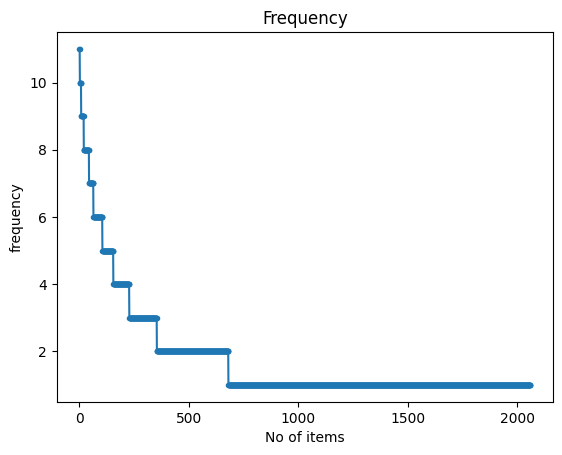

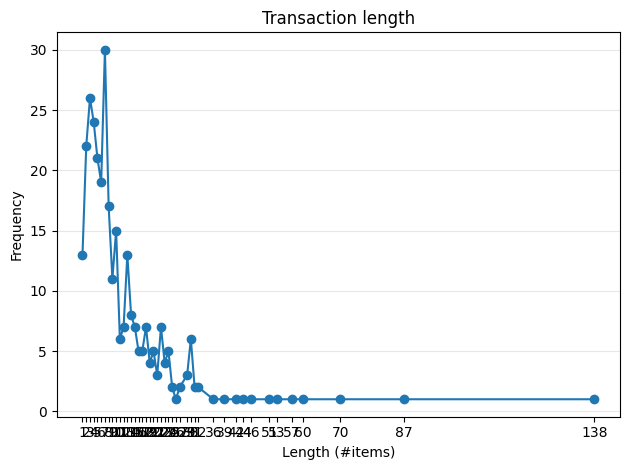

In [252]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_stock_-1.0.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 416
Number of items : 2586
Minimum Transaction Size : 1
Average Transaction Size : 10.790865384615385
Maximum Transaction Size : 200
Standard Deviation Transaction Size : 18.26124556638251
Variance in Transaction Sizes : 334.27663924930494
Sparsity : 0.9958271982271403


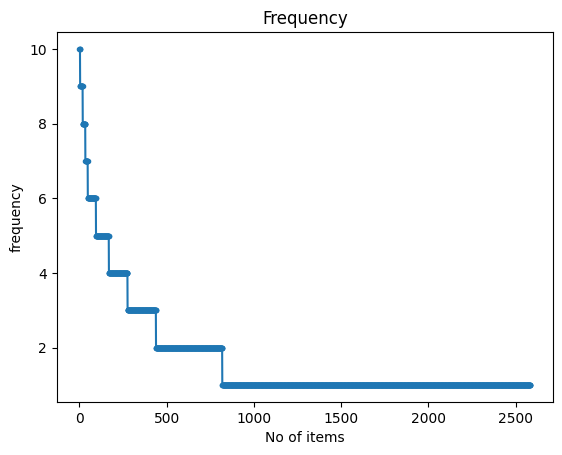

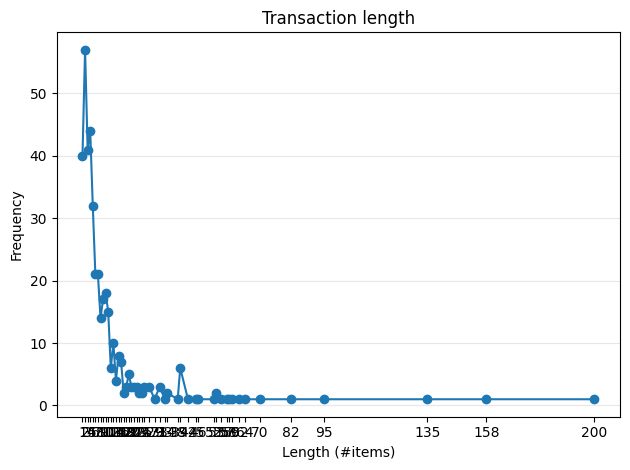

In [253]:
obj = tds.TransactionalDatabase('td_freq_stock_0.0.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 108
Number of items : 1103
Minimum Transaction Size : 1
Average Transaction Size : 14.333333333333334
Maximum Transaction Size : 92
Standard Deviation Transaction Size : 16.86273559811254
Variance in Transaction Sizes : 287.0093457943925
Sparsity : 0.9870051375037776


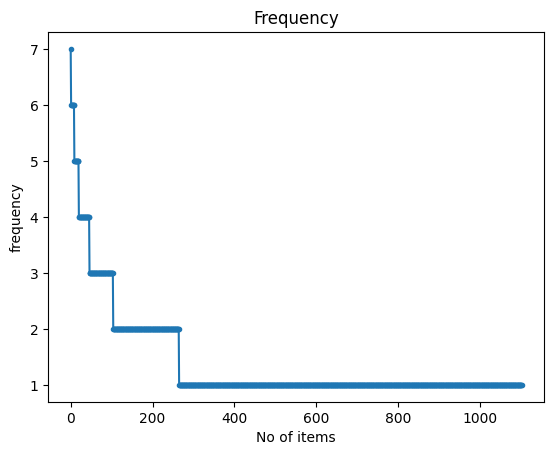

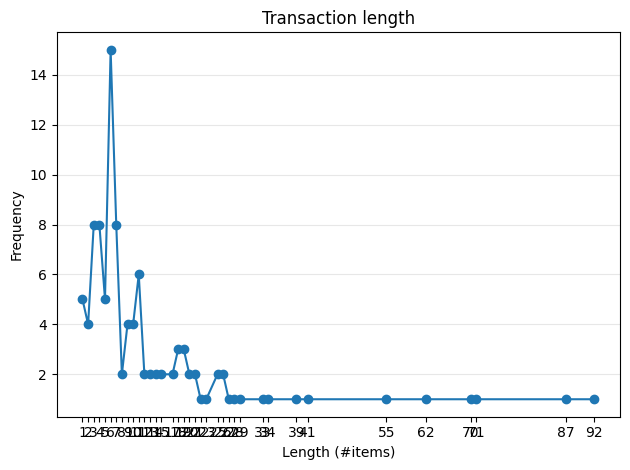

In [254]:
obj = tds.TransactionalDatabase('td_freq_stock_1.0.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

In [255]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6 # change from 9 to 6 (because of smaller datasets)
obj1 = alg.FPGrowth(iFile='td_freq_stock_-1.0.csv', minSup=minSup)
obj1.mine()
frequentPatternsDF_n1= obj1.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_n1)))
print('Runtime: ' + str(obj1.getRuntime()))
obj1.save('freq_patterns_stock-1_minSup6.txt')
frequentPatternsDF_n1  # negative 1

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 105
Runtime: 0.0025162696838378906


,Patterns,Support
0,calls,6
1,companies,6
2,lot,6
3,next,6
4,first,6
...,...,...
100,sure,10
101,should,10
102,again,10
103,already,11


In [256]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj2 = alg.FPGrowth(iFile='td_freq_stock_0.0.csv', minSup=minSup)
obj2.mine()
frequentPatternsDF_0= obj2.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_0)))
print('Runtime: ' + str(obj2.getRuntime()))
obj2.save('freq_patterns_stock0_minSup6.txt')
frequentPatternsDF_0

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 99
Runtime: 0.003265857696533203


,Patterns,Support
0,big,6
1,talk,6
2,months,6
3,probably,6
4,doing,6
...,...,...
94,few,9
95,down,10
96,most,10
97,go,10


In [257]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj3 = alg.FPGrowth(iFile='td_freq_stock_1.0.csv', minSup=minSup)
obj3.mine()
frequentPatternsDF_p1= obj3.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_0)))
print('Runtime: ' + str(obj3.getRuntime()))
obj3.save('freq_patterns_stock1_minSup6.txt')
frequentPatternsDF_p1

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 99
Runtime: 0.0009479522705078125


,Patterns,Support
0,into,6
1,your,6
2,there,6
3,us,6
4,them,6
5,out,6
6,economy,6
7,way,6
8,has,7


In [258]:
import pandas as pd

# We group together all of the dataframes related to our found patterns
dfs = [frequentPatternsDF_n1, frequentPatternsDF_0, frequentPatternsDF_p1]

# Identify patterns that appear in more than one category
# Count how many times each pattern appears across all dataframes
pattern_counts = {}
for df in dfs:
    for pattern in df['Patterns']:
        if pattern not in pattern_counts:
            pattern_counts[pattern] = 1
        else:
            pattern_counts[pattern] += 1

unique_patterns = {pattern for pattern, count in pattern_counts.items() if count == 1}
total_patterns_count = sum(len(df) for df in dfs)
discarded_patterns_count = total_patterns_count - len(unique_patterns)

# For each category, filter the patterns to keep only the unique ones
filtered_dfs = []
for df in dfs:
    filtered_df = df[df['Patterns'].isin(unique_patterns)]
    filtered_dfs.append(filtered_df)

final_pattern_df = pd.concat(filtered_dfs, ignore_index=True)

final_pattern_df = final_pattern_df.sort_values(by='Support', ascending=False)

print(final_pattern_df)
print(f"Number of patterns discarded: {discarded_patterns_count}")

           Patterns  Support
81            after       11
157            most       10
77              day       10
80            again       10
79           should       10
..              ...      ...
36             lost        6
35           silver        6
34           though        6
33   administration        6
83           months        6

[166 rows x 2 columns]
Number of patterns discarded: 47


In [259]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Convert 'text' column into term-document matrix using CountVectorizer
count_vect = CountVectorizer()
X_tdm = count_vect.fit_transform(data['text'])
terms = count_vect.get_feature_names_out()

# Tokenize the sentences into sets of unique words
data['tokenized_text'] = data['text'].str.split().apply(set)

pattern_matrix = pd.DataFrame(0, index=data.index, columns=final_pattern_df['Patterns'])

# Iterate over each pattern and check if all words in the pattern are present in the tokenized sentence
for pattern in final_pattern_df['Patterns']:
    pattern_words = set(pattern.split())
    pattern_matrix[pattern] = data['tokenized_text'].apply(lambda x: 1 if pattern_words.issubset(x) else 0)

tdm_df = pd.DataFrame(X_tdm.toarray(), columns=terms, index=data.index)
augmented_df = pd.concat([tdm_df, pattern_matrix], axis=1)

augmented_df

,00,000,01378,02,027,03,06,08,10,100,...,doing,probably,companies,talk,gonna,lost,silver,though,administration,months
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
844,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
845,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [260]:
# Exercise 17:
# FAE top-k
from PAMI.frequentPattern.topk import FAE as alg
for k_count in [50, 100, 150]: # adjusted k values (because of smaller datasets)
    obj3 = alg.FAE(iFile='td_freq_stock_1.0.csv', k=k_count)
    obj3.mine()
    frequentPatternsDF_p1 = obj3.getPatternsAsDataFrame()
    obj3.save(f'freq_patterns_1.0_top_{k_count}.txt')
    print('k: ' + str(k_count))
    print('Total No of patterns: ' + str(len(frequentPatternsDF_p1)))
    print('Runtime: ' + str(obj3.getRuntime()))

print('-' * 40)

# MaxFPGrowth
from PAMI.frequentPattern.maximal import MaxFPGrowth as alg
for minSup in [3, 6, 9]:
    obj3 = alg.MaxFPGrowth(iFile='td_freq_stock_1.0.csv', minSup=minSup)
    obj3.mine()
    frequentPatternsDF_p1 = obj3.getPatternsAsDataFrame()
    obj3.save(f'freq_patterns_1.0_max_{minSup}.txt')
    print('MinSup: ' + str(minSup))
    print('Total No of patterns: ' + str(len(frequentPatternsDF_p1)))
    print('Runtime: ' + str(obj3.getRuntime())) 

# FAE top-k: The output is usually dominated by common nouns at the beginning, then the words related to stock will appear (e.g., economy, tariffs, hold). 
# Because the dataset is small, there is no high redundancy before top_k=100, but there is a little bit redundancy between 101-150.
# MaxFPGrowth: Again, because the dataset is too small, the result will be very similar to the output of top_k. When minSup=9, there are no more words.


 TopK frequent patterns were successfully generated using FAE algorithm.
k: 50
Total No of patterns: 50
Runtime: 0.002129793167114258
 TopK frequent patterns were successfully generated using FAE algorithm.
k: 100
Total No of patterns: 100
Runtime: 0.0016980171203613281
 TopK frequent patterns were successfully generated using FAE algorithm.
k: 150
Total No of patterns: 150
Runtime: 0.009327173233032227
----------------------------------------
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
MinSup: 3
Total No of patterns: 98
Runtime: 0.0013871192932128906
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
MinSup: 6
Total No of patterns: 9
Runtime: 0.0004961490631103516
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
MinSup: 9
Total No of patterns: 0
Runtime: 0.0004100799560546875


### Dimensionality Reduction

In [261]:
#Applying dimensionality reduction with only the document-term frequency data
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

X_pca_tdm = PCA(n_components=2).fit_transform(tdm_df.values)
X_tsne_tdm = TSNE(n_components=2).fit_transform(tdm_df.values)
X_umap_tdm = umap.UMAP(n_components=2).fit_transform(tdm_df.values)

In [262]:
print("PCA:", X_pca_tdm.shape)
print("t-SNE:", X_tsne_tdm.shape)
print("UMAP:", X_umap_tdm.shape)

PCA: (847, 2)
t-SNE: (847, 2)
UMAP: (847, 2)


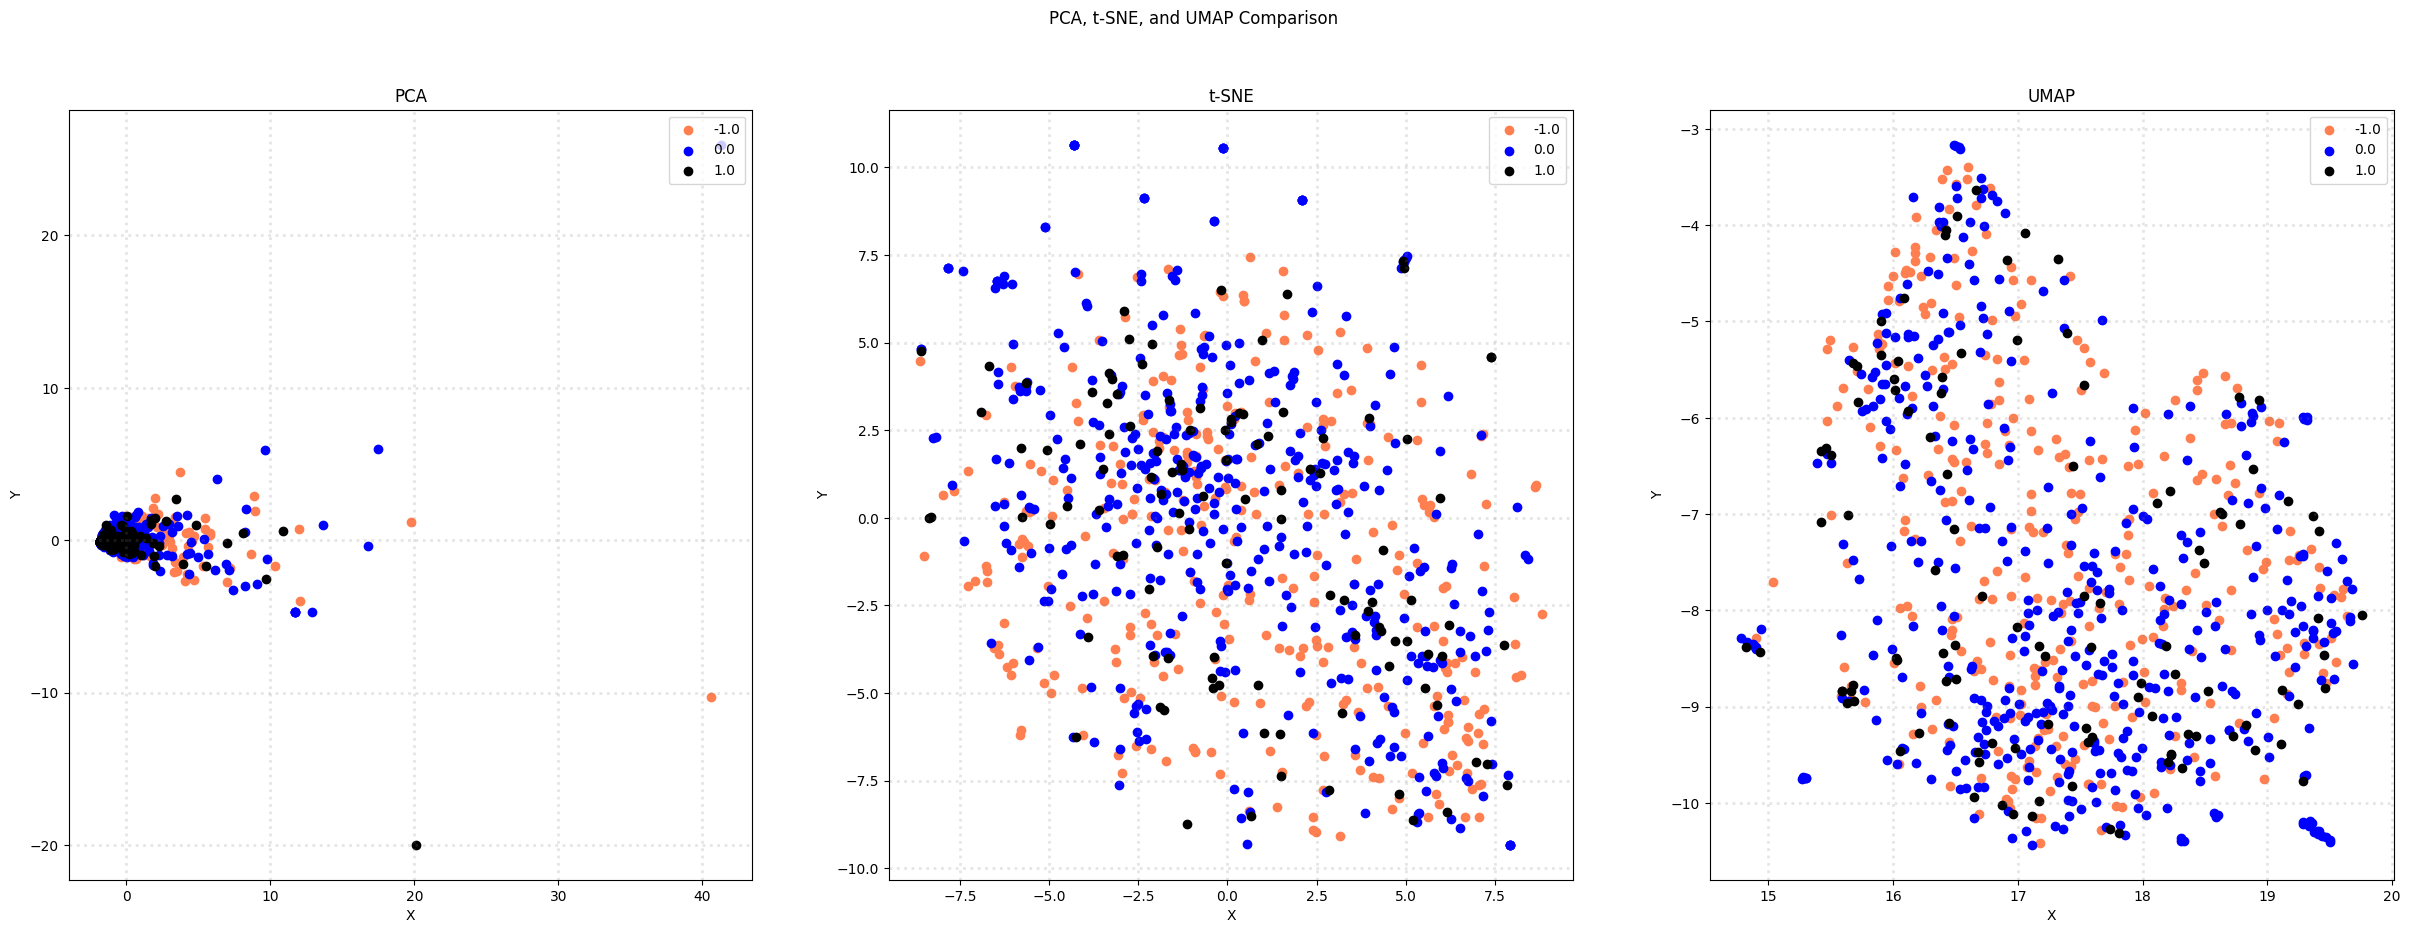

In [263]:
# Plot the results in subplots
col = ['coral', 'blue', 'black', 'orange']
categories = data['label'].unique() 

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
fig.suptitle('PCA, t-SNE, and UMAP Comparison')

def plot_scatter(ax, X_reduced, title):
    for c, category in zip(col, categories):
        xs = X_reduced[data['label'] == category].T[0]
        ys = X_reduced[data['label'] == category].T[1]
        ax.scatter(xs, ys, c=c, marker='o', label=category)
    
    ax.grid(color='gray', linestyle=':', linewidth=2, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

plot_scatter(axes[0], X_pca_tdm, 'PCA')
plot_scatter(axes[1], X_tsne_tdm, 't-SNE')
plot_scatter(axes[2], X_umap_tdm, 'UMAP')

plt.show()

In [264]:
#Applying dimensionality reduction with both the document-term frequency data and the pattern derived data
X_pca_aug = PCA(n_components=2).fit_transform(augmented_df.values)
X_tsne_aug = TSNE(n_components=2).fit_transform(augmented_df.values)
X_umap_aug = umap.UMAP(n_components=2).fit_transform(augmented_df.values)

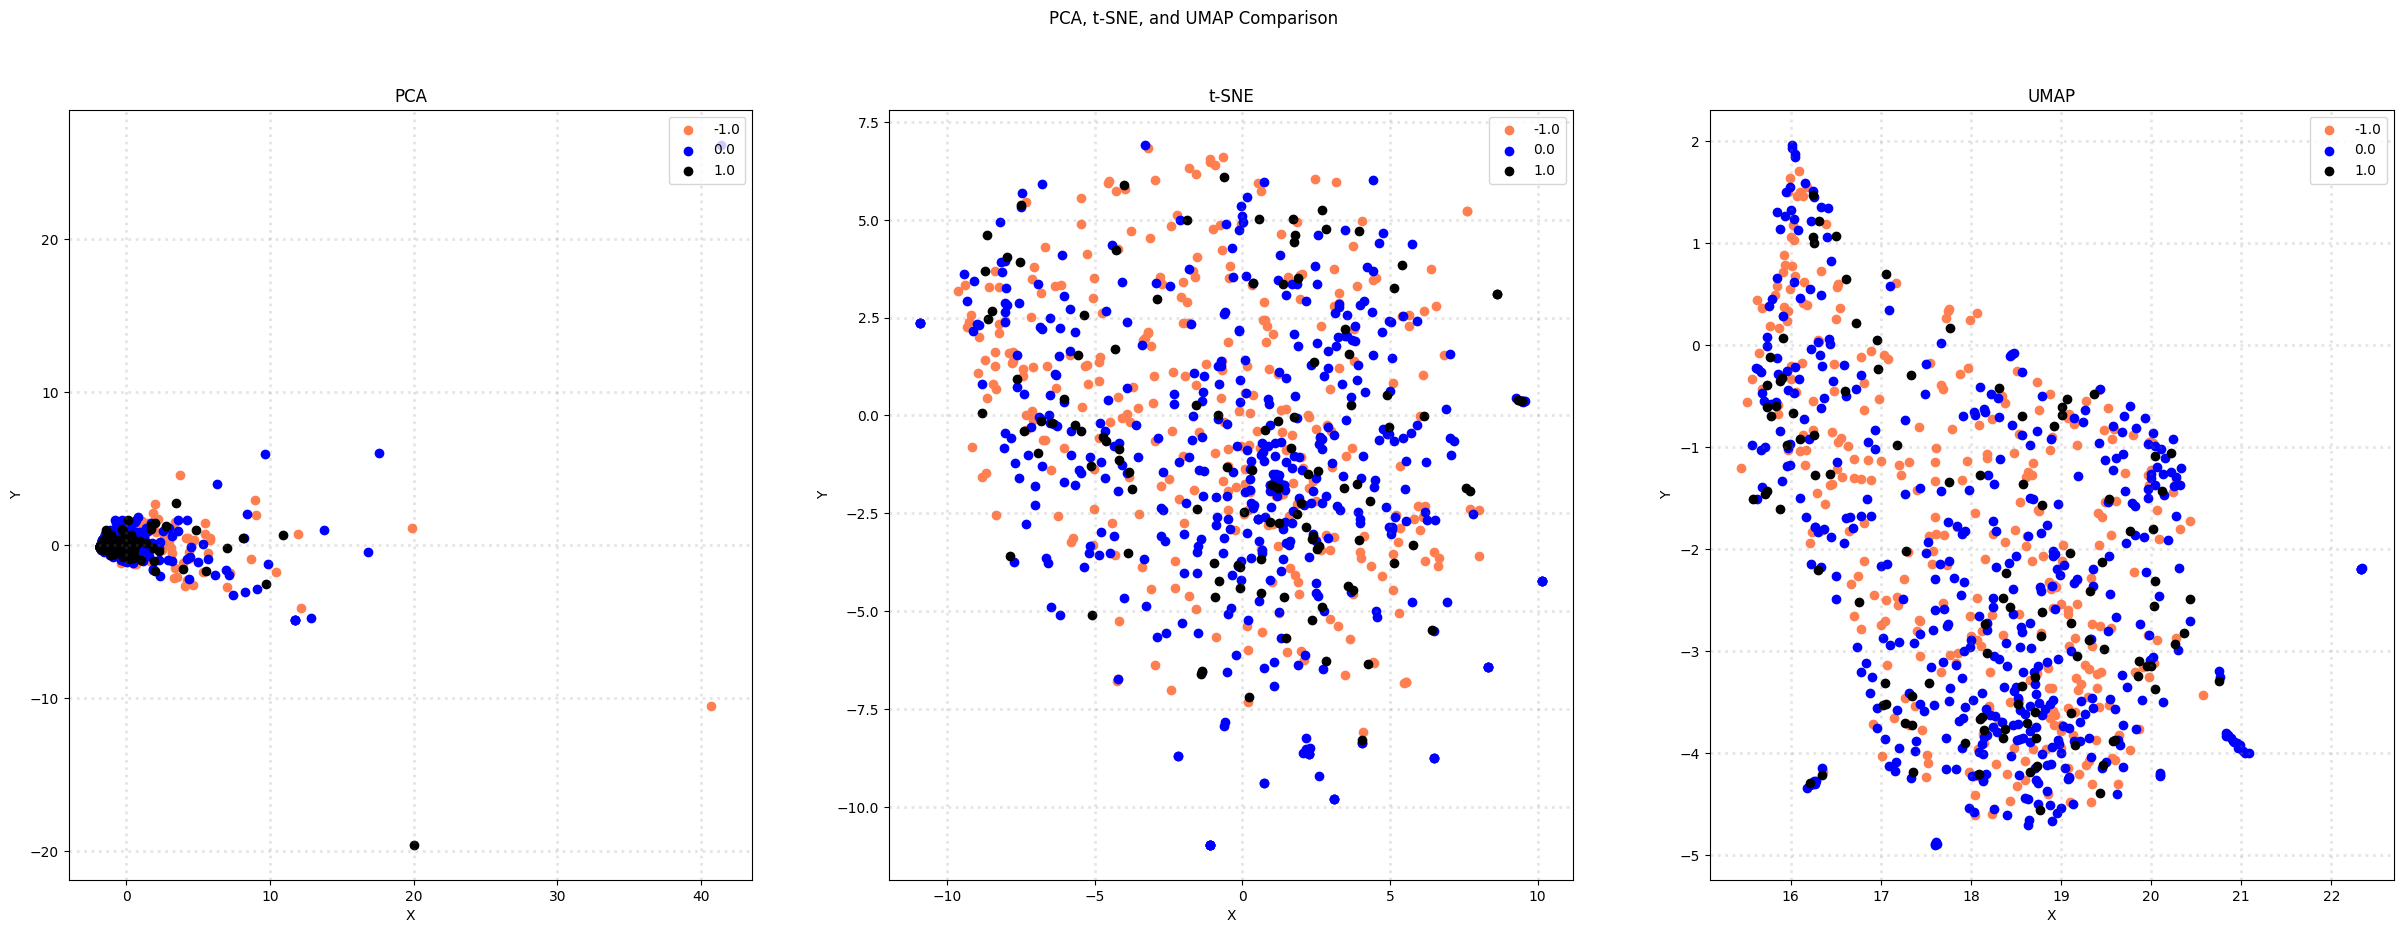

In [265]:
col = ['coral', 'blue', 'black', 'orange']
categories = data['label'].unique() 

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
fig.suptitle('PCA, t-SNE, and UMAP Comparison')

def plot_scatter(ax, X_reduced, title):
    for c, category in zip(col, categories):
        xs = X_reduced[data['label'] == category].T[0]
        ys = X_reduced[data['label'] == category].T[1]
        ax.scatter(xs, ys, c=c, marker='o', label=category)
    
    ax.grid(color='gray', linestyle=':', linewidth=2, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

plot_scatter(axes[0], X_pca_aug, 'PCA')
plot_scatter(axes[1], X_tsne_aug, 't-SNE')
plot_scatter(axes[2], X_umap_aug, 'UMAP')

plt.show()

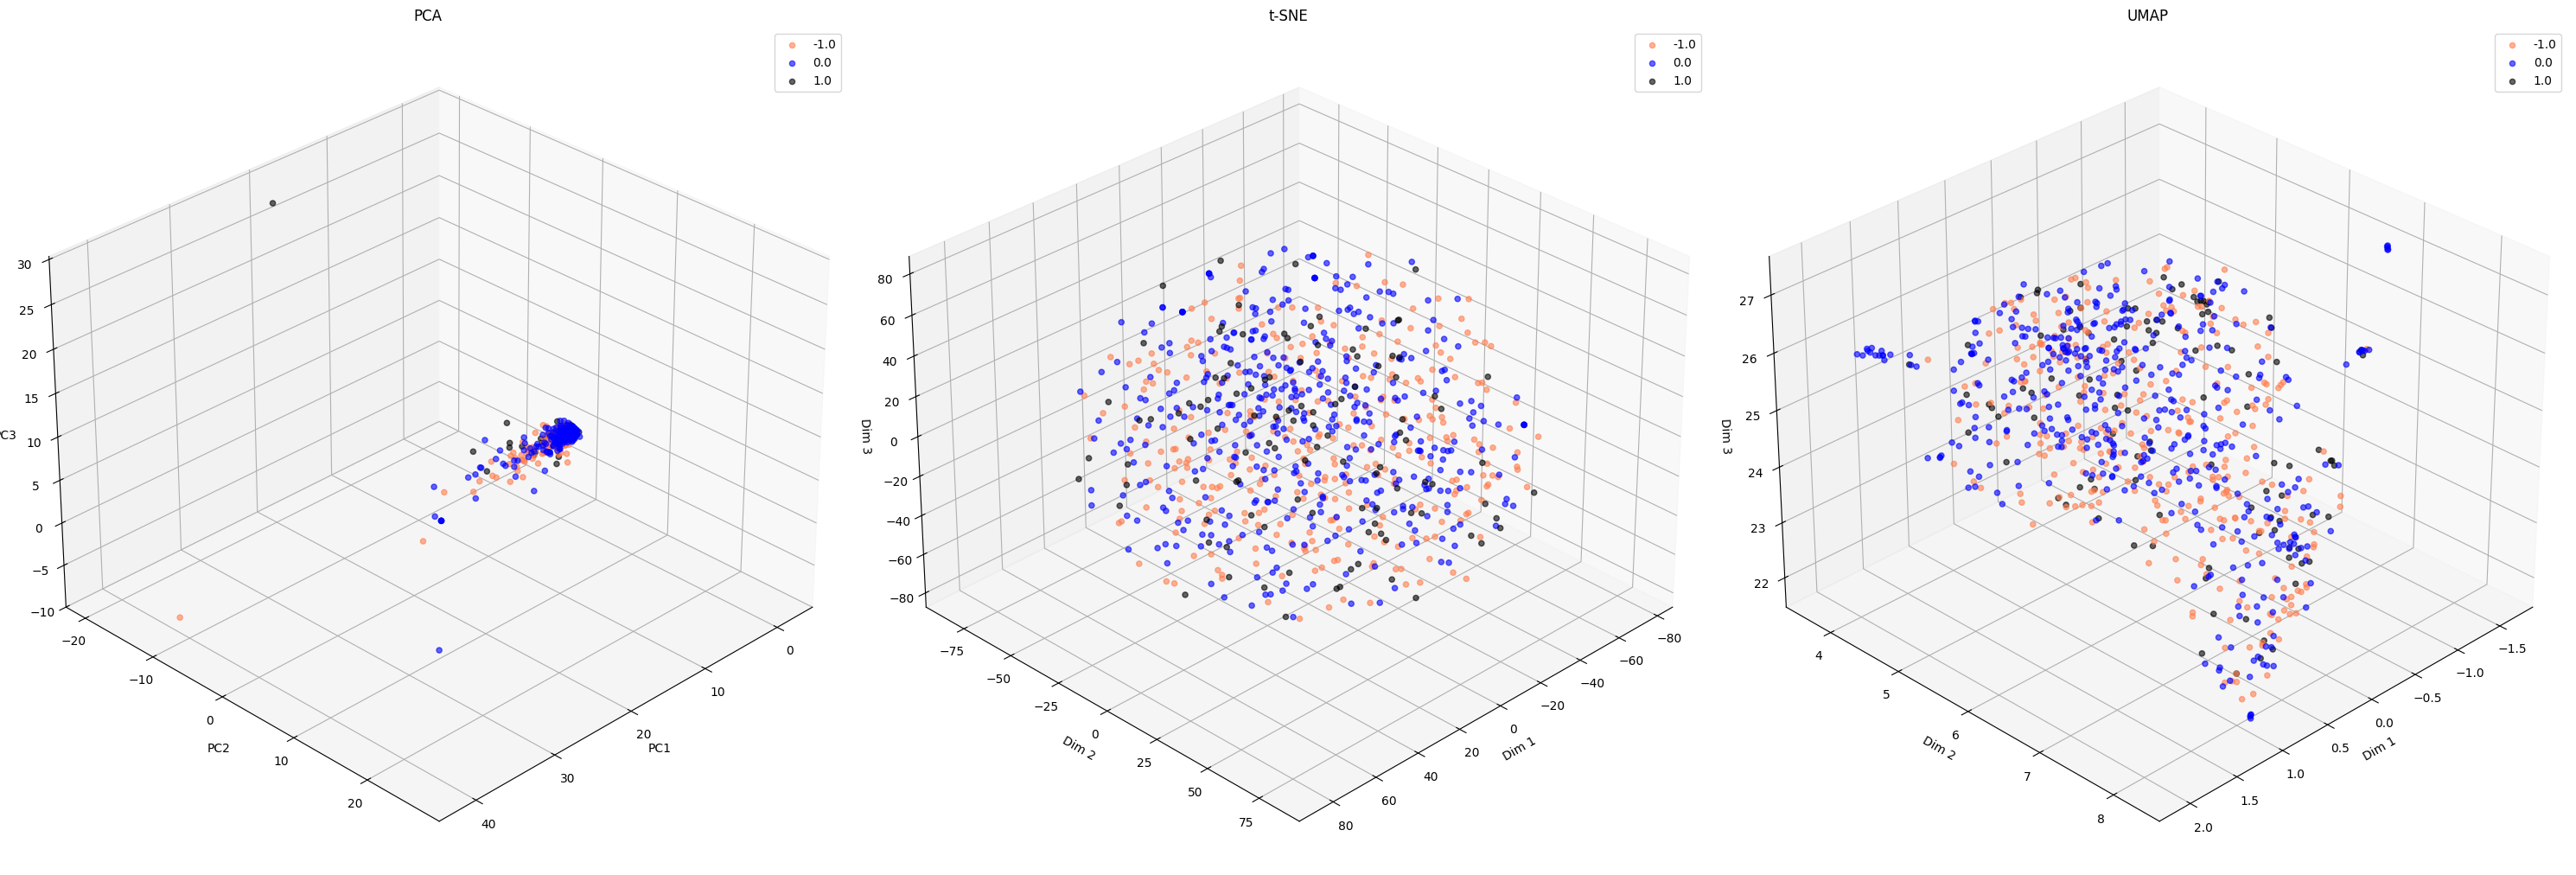

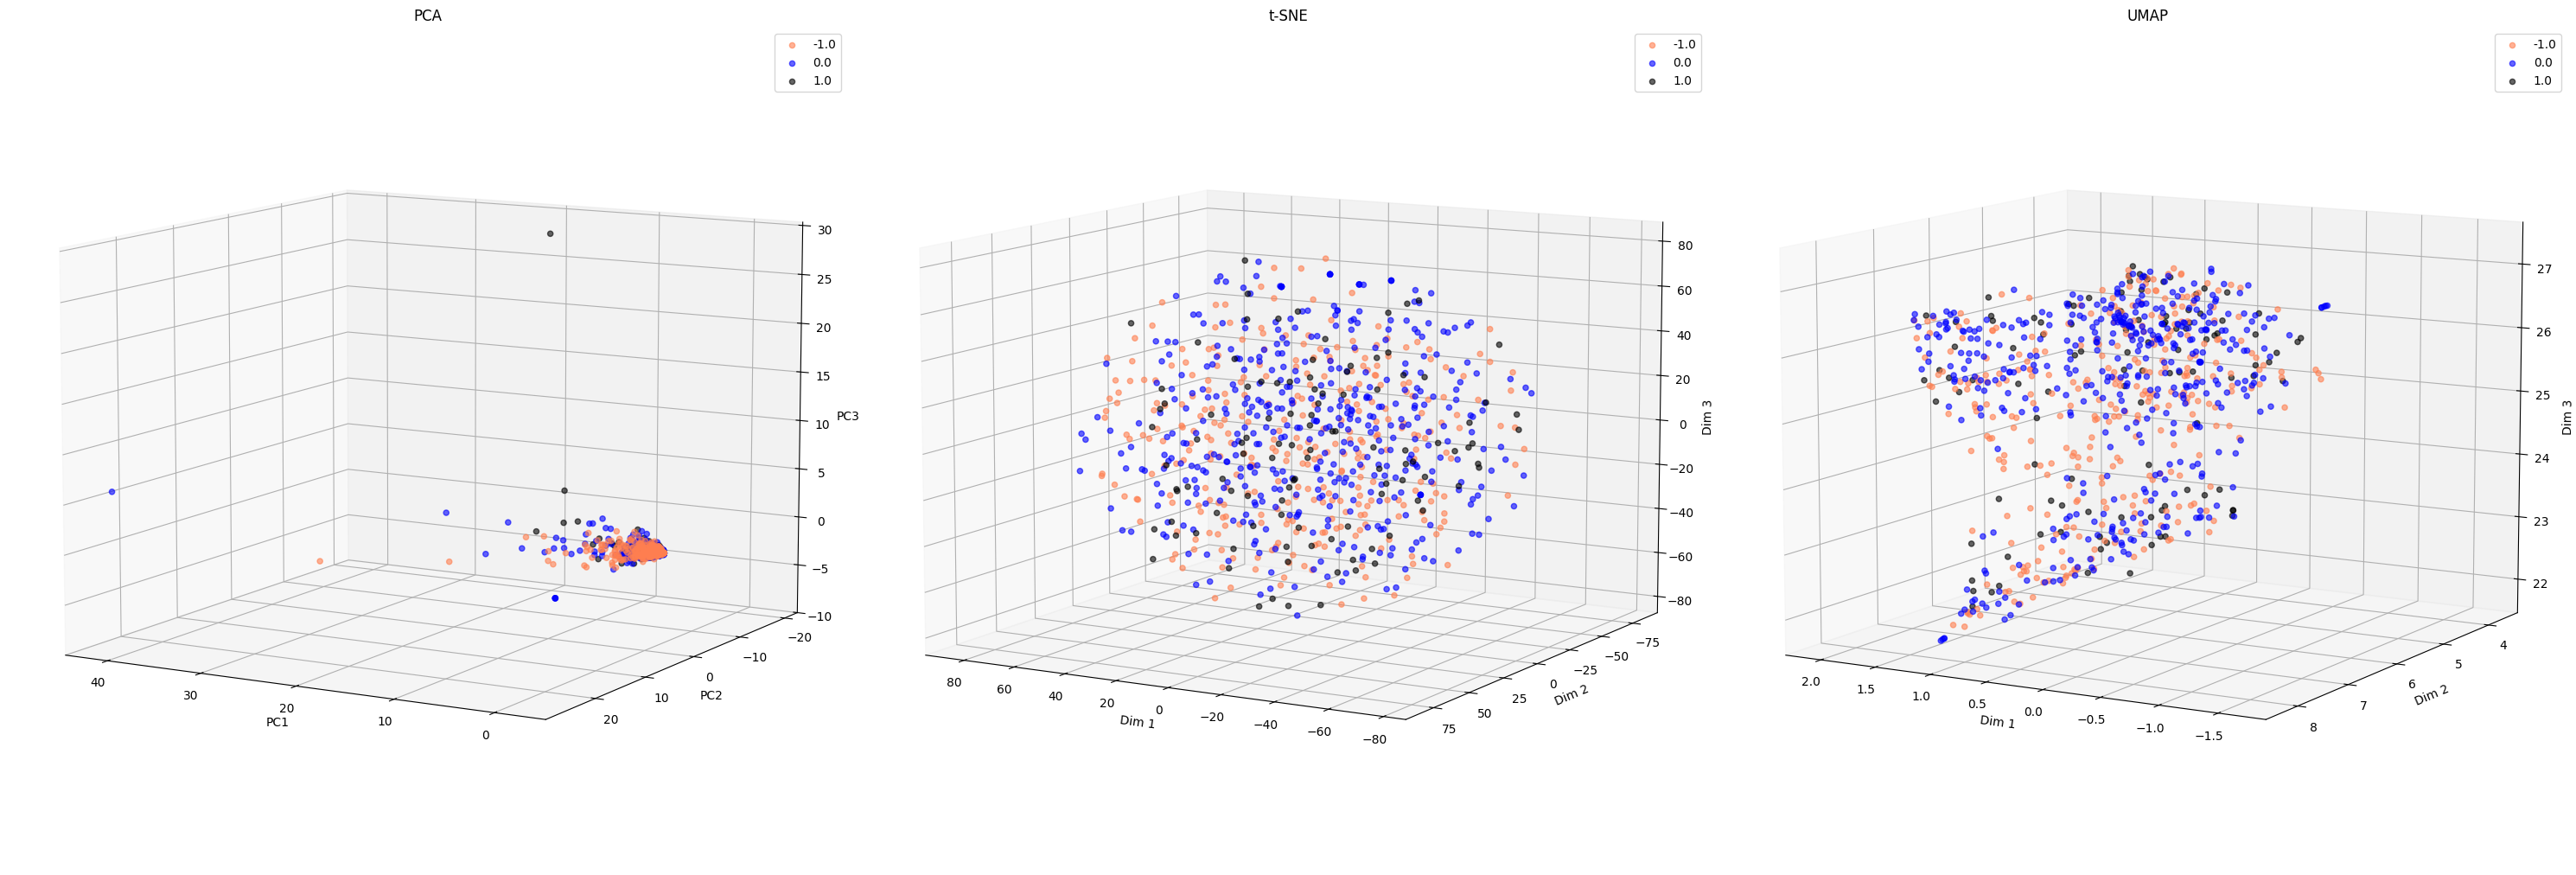

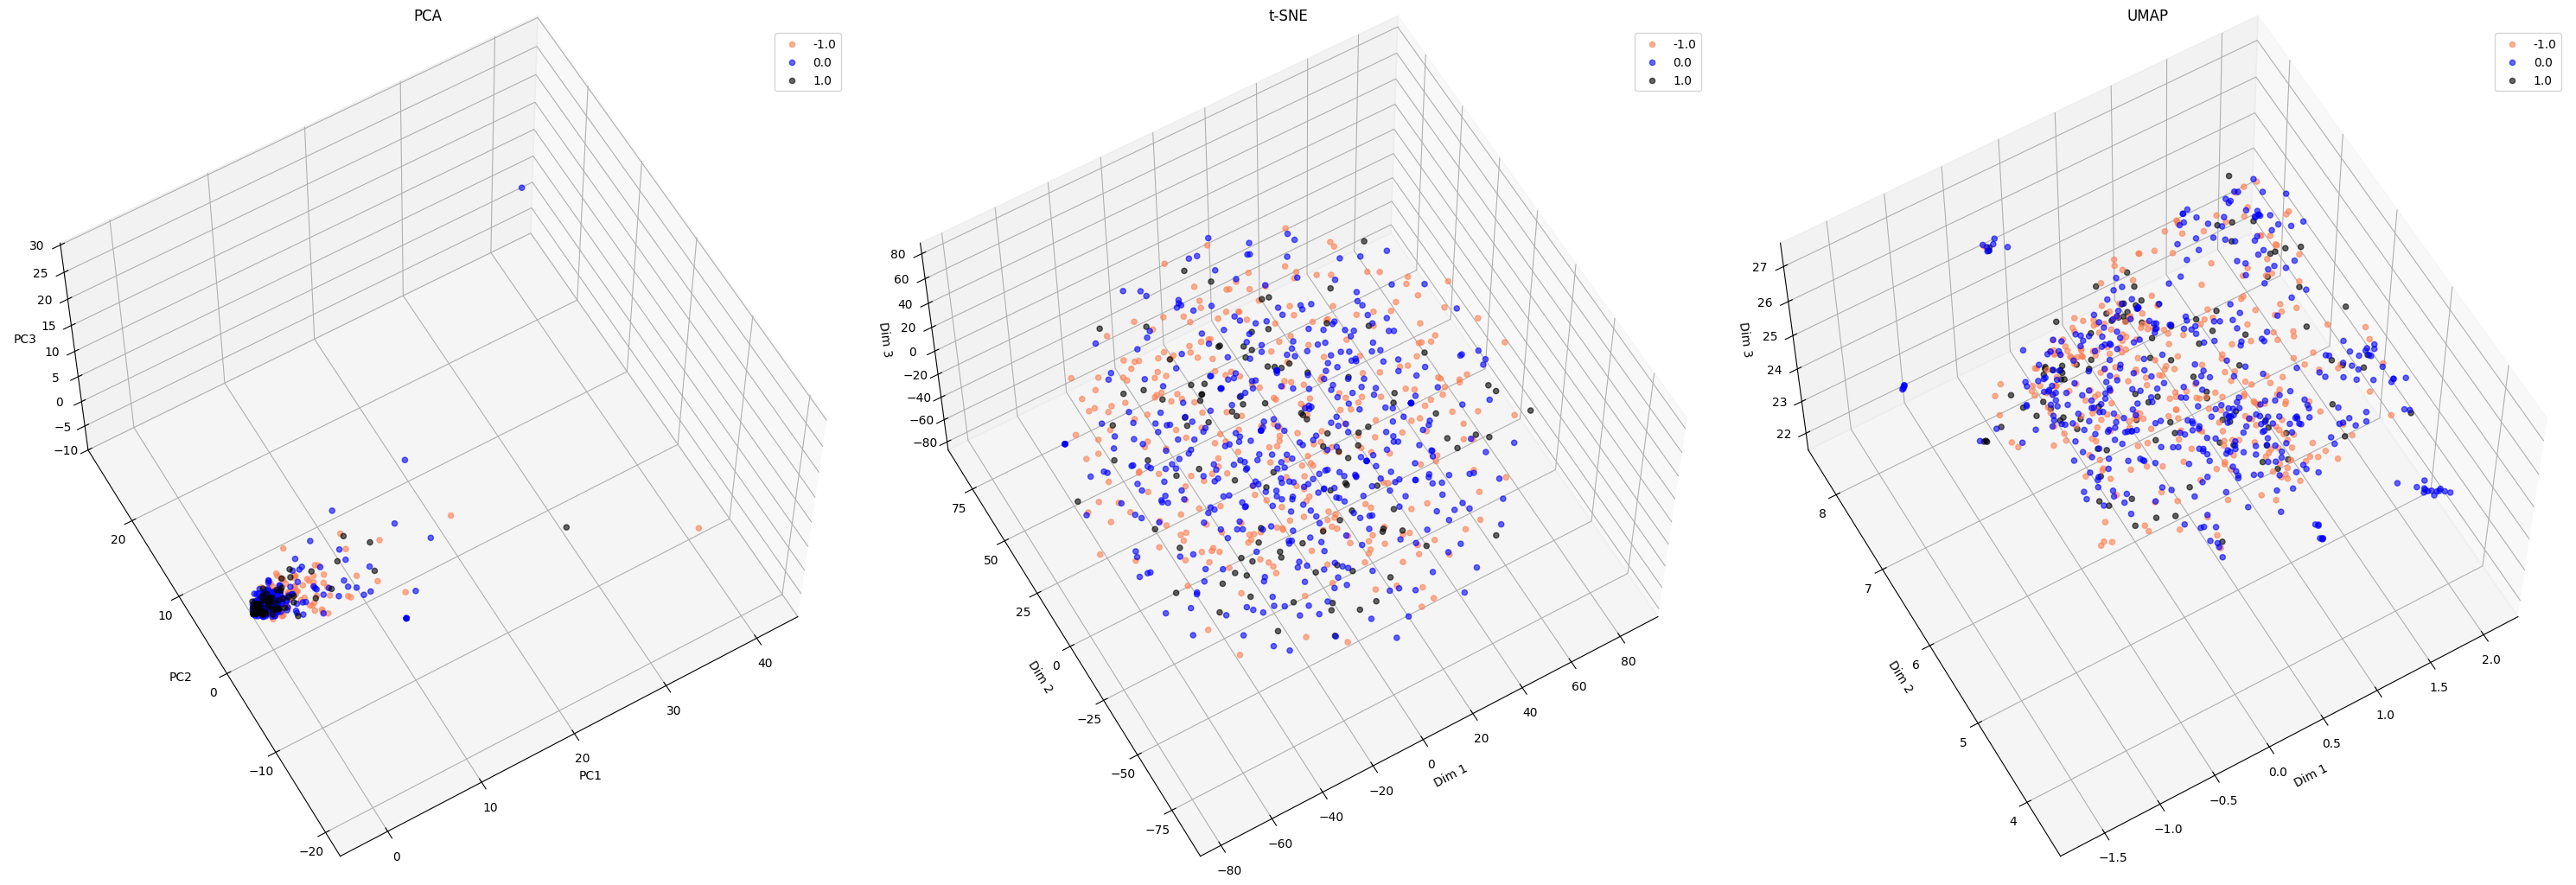

In [266]:
# Exercise 18:
from mpl_toolkits.mplot3d import Axes3D

X_pca_aug_3d = PCA(n_components=3).fit_transform(augmented_df.values)
X_tsne_aug_3d = TSNE(n_components=3).fit_transform(augmented_df.values)
X_umap_aug_3d = umap.UMAP(n_components=3).fit_transform(augmented_df.values)

col = ['coral', 'blue', 'black', 'orange']
categories = data['label'].unique()

# Define three different viewing angles (elevation, azimuth)
angles = [
    (30, 45),   # Angle 1: moderate elevation, 45 degrees rotation
    (10, 120),  # Angle 2: low elevation, 120 degrees rotation
    (60, 240)   # Angle 3: high elevation, 240 degrees rotation
]

# Create 3D plots for each angle
for angle_idx, (elev, azim) in enumerate(angles, 1):
    fig = plt.figure(figsize=(30, 10))
    
    # PCA subplot
    ax1 = fig.add_subplot(131, projection='3d')
    for c, category in zip(col, categories):
        mask = data['label'] == category
        ax1.scatter(X_pca_aug_3d[mask, 0], 
                   X_pca_aug_3d[mask, 1], 
                   X_pca_aug_3d[mask, 2], 
                   c=c, marker='o', label=category, alpha=0.6)
    ax1.set_title('PCA')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_zlabel('PC3')
    ax1.legend(loc='upper right')
    ax1.view_init(elev=elev, azim=azim)
    
    ax2 = fig.add_subplot(132, projection='3d')
    for c, category in zip(col, categories):
        mask = data['label'] == category
        ax2.scatter(X_tsne_aug_3d[mask, 0], 
                   X_tsne_aug_3d[mask, 1], 
                   X_tsne_aug_3d[mask, 2], 
                   c=c, marker='o', label=category, alpha=0.6)
    ax2.set_title('t-SNE')
    ax2.set_xlabel('Dim 1')
    ax2.set_ylabel('Dim 2')
    ax2.set_zlabel('Dim 3')
    ax2.legend(loc='upper right')
    ax2.view_init(elev=elev, azim=azim)
    
    ax3 = fig.add_subplot(133, projection='3d')
    for c, category in zip(col, categories):
        mask = data['label'] == category
        ax3.scatter(X_umap_aug_3d[mask, 0], 
                   X_umap_aug_3d[mask, 1], 
                   X_umap_aug_3d[mask, 2], 
                   c=c, marker='o', label=category, alpha=0.6)
    ax3.set_title('UMAP')
    ax3.set_xlabel('Dim 1')
    ax3.set_ylabel('Dim 2')
    ax3.set_zlabel('Dim 3')
    ax3.legend(loc='upper right')
    ax3.view_init(elev=elev, azim=azim)
    
    plt.tight_layout()
    plt.show()

# PCA: Again, the majority of data is clustered in one place, with only a few scattered points.
# t-SNE: The data is concentrated in an ellipse. However, there are no clear boundaries between the classes, which is not enough to achieve perfect clustering.
# UMAP: While more dispersed, but still not enough to achieve perfect clustering.

### Discretization and Binarization

In [267]:
from sklearn import preprocessing
mlb = preprocessing.LabelBinarizer()
mlb.fit(data.label)
data['bin_label'] = mlb.transform(data['label']).tolist()
data[0:9]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label,unigrams,tokenized_text,bin_label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0,"[Calls, on, retards]","{retards, on, Calls}","[1, 0, 0]"
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0,"[Stunt, as, in, like, why, did, they, even, ma...","{big, should, like, as, politics, deal, they, ...","[0, 1, 0]"
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0,"[Seeing, lots, of, red, in, the, ticker, .]","{red, ticker., lots, of, in, Seeing, the}","[0, 1, 0]"
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0,"[Vision, Marine, Technologies, Inc., is, rewri...","{[](), watercraft., pushes, –, Torrente., come...","[0, 0, 1]"
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0,"[He, didn, ’, t, say, thank, you, .]","{He, thank, didn’t, say, you.}","[1, 0, 0]"
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0,"[Hoping, to, ejaculate, in, wet, warm, puss, t...","{to, Hoping, wish, tonight,, warm, me, luck, i...","[0, 1, 0]"
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0,"[Trump, will, respond, to, china, increasing, ...","{all, down, their, quickly, going, very, Powel...","[1, 0, 0]"
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0,"[Confirmed, not, a, trap, ., Its, been, like, ...","{slowly, let, like, word, this, Its, a, by, 2,...","[0, 1, 0]"
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0,"[Am, I, the, only, one, seeing, the, cup, &, h...","{The, trend, week, pivot, &, Am, high?, Third,...","[0, 0, 1]"


### Data Exploration

In [268]:
# Exercise 20:
from sklearn.preprocessing import binarize
from sklearn.metrics.pairwise import cosine_similarity

document_to_transform_1 = []
random_record_1 = data.iloc[0]
random_record_1 = random_record_1['text']
document_to_transform_1.append(random_record_1)

document_to_transform_2 = []
random_record_2 = data.iloc[400]
random_record_2 = random_record_2['text']
document_to_transform_2.append(random_record_2)

document_to_transform_3 = []
random_record_3 = data.iloc[800]
random_record_3 = random_record_3['text']
document_to_transform_3.append(random_record_3)

print(data.iloc[0])
print(data.iloc[400])
print(data.iloc[800])

# Transform sentence with Vectorizers
document_vector_count_1 = count_vect.transform(document_to_transform_1)
document_vector_count_2 = count_vect.transform(document_to_transform_2)
document_vector_count_3 = count_vect.transform(document_to_transform_3)

# Binarize vectors to simplify: 0 for abscence, 1 for prescence
document_vector_count_1_bin = binarize(document_vector_count_1)
document_vector_count_2_bin = binarize(document_vector_count_2)
document_vector_count_3_bin = binarize(document_vector_count_3)

# Calculate Cosine Similarity
cos_sim_count_1_2 = cosine_similarity(document_vector_count_1, document_vector_count_2, dense_output=True)
cos_sim_count_1_3 = cosine_similarity(document_vector_count_1, document_vector_count_3, dense_output=True)
cos_sim_count_2_3 = cosine_similarity(document_vector_count_2, document_vector_count_3, dense_output=True)

print("Cosine Similarity using count bw 1 and 2: %(x)f" %{"x":cos_sim_count_1_2})
print("Cosine Similarity using count bw 1 and 3: %(x)f" %{"x":cos_sim_count_1_3})
print("Cosine Similarity using count bw 2 and 3: %(x)f" %{"x":cos_sim_count_2_3})

# Cosine similarity here refers to how many words appear in both strings. However, even for articles in the same category, common vocabulary and sentence length can affect the cosine similarity of articles in one category, potentially causing it to be lower than that of other categories. 
# Therefore, good string preprocessing may be necessary to make cosine similarity more meaningful.

type                                                      comment
datetime                                      2025-04-11 17:29:56
post_id                                                   mmli62w
subreddit                                          wallstreetbets
title             Retardation is on the menu boys! WSB is so back
author                                               StickyTip420
url                          https://i.redd.it/0yq2ftren8ue1.jpeg
upvotes                                                         0
downvotes                                                     NaN
upvote_ratio                                                  NaN
text                                             Calls on retards
subjectivity                                                  1.0
polarity                                                     -0.9
sentiment                                                    -1.0
entities                                                       []
label     

/var/folders/8s/q03474593k73hgwq2b8n3z4w0000gn/T/ipykernel_38247/3422934315.py:39: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/var/folders/8s/q03474593k73hgwq2b8n3z4w0000gn/T/ipykernel_38247/3422934315.py:40: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/var/folders/8s/q03474593k73hgwq2b8n3z4w0000gn/T/ipykernel_38247/3422934315.py:41: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



### Data Classification

In [269]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Create a mapping from numerical labels to category names
category_mapping = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

# Convert the numerical category labels to text labels
target_names = [category_mapping[label] for label in sorted(category_mapping.keys())]

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(tdm_df, data['label'], test_size=0.3, random_state=42)

In [270]:
X_train

,00,000,01378,02,027,03,06,08,10,100,...,yours,yourself,yourselves,youtube,yoyo,yup,zero,zgld,zone,zsil
739,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
140,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
173,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
552,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
106,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
270,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [271]:
X_test

,00,000,01378,02,027,03,06,08,10,100,...,yours,yourself,yourselves,youtube,yoyo,yup,zero,zgld,zone,zsil
457,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
342,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
280,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
275,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
548,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
351,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
136,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [272]:
# Train the Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

Accuracy: 0.592156862745098

Classification Report:
               precision    recall  f1-score   support

    Negative     0.5854    0.7347    0.6516        98
     Neutral     0.6393    0.6446    0.6420       121
    Positive     0.1000    0.0278    0.0435        36

    accuracy                         0.5922       255
   macro avg     0.4416    0.4690    0.4457       255
weighted avg     0.5425    0.5922    0.5612       255



In [273]:
# Exercise 21-22
# Convert the numerical category labels to text labels
target_names = [category_mapping[label] for label in sorted(category_mapping.keys())]

X_train, X_test, y_train, y_test = train_test_split(augmented_df, data['label'], test_size=0.3, random_state=42)

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

Accuracy: 0.6078431372549019

Classification Report:
               precision    recall  f1-score   support

    Negative     0.5984    0.7449    0.6636        98
     Neutral     0.6585    0.6694    0.6639       121
    Positive     0.1000    0.0278    0.0435        36

    accuracy                         0.6078       255
   macro avg     0.4523    0.4807    0.4570       255
weighted avg     0.5566    0.6078    0.5762       255



### Decision Tree Classifier

In [274]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(tdm_df, data['label'], test_size=0.3, random_state=42)

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (TDM): 0.49019607843137253

Classification Report:
               precision    recall  f1-score   support

    Negative     0.4878    0.4082    0.4444        98
     Neutral     0.5294    0.6694    0.5912       121
    Positive     0.2000    0.1111    0.1429        36

    accuracy                         0.4902       255
   macro avg     0.4057    0.3962    0.3928       255
weighted avg     0.4669    0.4902    0.4715       255



In [275]:
# Exercise 24
X_train, X_test, y_train, y_test = train_test_split(augmented_df, data['label'], test_size=0.3, random_state=42)

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (TDM): 0.5058823529411764

Classification Report:
               precision    recall  f1-score   support

    Negative     0.5000    0.3776    0.4302        98
     Neutral     0.5298    0.7355    0.6159       121
    Positive     0.2308    0.0833    0.1224        36

    accuracy                         0.5059       255
   macro avg     0.4202    0.3988    0.3895       255
weighted avg     0.4761    0.5059    0.4749       255



### TF-IDF

In [276]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(data['text'])

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_feature_names,
    index=data.index
)

print(f"Number of documents: {tfidf_matrix.shape[0]}")
print(f"Number of unique terms: {tfidf_matrix.shape[1]}")
print(tfidf_df.iloc[:5, :10])

Number of documents: 847
Number of unique terms: 4346
    00  000  01378   02  027   03   06   08   10  100
0  0.0  0.0    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3  0.0  0.0    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
4  0.0  0.0    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [277]:
# Experiment 1: Multi-Class Classification (-1/0/1)

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import classification_report, accuracy_score

category_mapping = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
target_names = [category_mapping[label] for label in sorted(category_mapping.keys())]

# 1. word frequency features (MultinomialNB)
print("\n" + "-"*80)
print("1. word frequency features")

X_train_freq, X_test_freq, y_train, y_test = train_test_split(
    tdm_df, data['label'], test_size=0.3, random_state=42
)

nb_freq = MultinomialNB()
nb_freq.fit(X_train_freq, y_train)
y_pred_freq = nb_freq.predict(X_test_freq)

print("\nAccuracy:", accuracy_score(y_test, y_pred_freq))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_freq, target_names=target_names, digits=4))

# 2. TF-IDF features (GaussianNB)
print("\n" + "-"*80)
print("2. TF-IDF features")

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    tfidf_df, data['label'], test_size=0.3, random_state=42
)

nb_tfidf = GaussianNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

print("\nAccuracy:", accuracy_score(y_test, y_pred_tfidf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=target_names, digits=4))

# 3. word frequency (augmented, MultinomialNB)
print("\n" + "-"*80)
print("3. word frequency (augmented)")

X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    augmented_df, data['label'], test_size=0.3, random_state=42
)

nb_aug = MultinomialNB()
nb_aug.fit(X_train_aug, y_train)
y_pred_aug = nb_aug.predict(X_test_aug)

print("\nAccuracy:", accuracy_score(y_test, y_pred_aug))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_aug, target_names=target_names, digits=4))

# 4. TF-IDF (augmented, GaussianNB)
print("\n" + "="*80)
print("4. TF-IDF (augmented)")

tfidf_augmented_df = pd.concat([tfidf_df, pattern_matrix], axis=1)

X_train_tfidf_aug, X_test_tfidf_aug, y_train, y_test = train_test_split(
    tfidf_augmented_df, data['label'], test_size=0.3, random_state=42
)

nb_tfidf_aug = GaussianNB()
nb_tfidf_aug.fit(X_train_tfidf_aug, y_train)
y_pred_tfidf_aug = nb_tfidf_aug.predict(X_test_tfidf_aug)

print("\nAccuracy:", accuracy_score(y_test, y_pred_tfidf_aug))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf_aug, target_names=target_names, digits=4))

# Analysis
results = {
    'Model': [
        'Word Freq (MultinomialNB)',
        'TF-IDF (GaussianNB)',
        'Word Freq + Patterns (MultinomialNB)',
        'TF-IDF + Patterns (GaussianNB)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_freq),
        accuracy_score(y_test, y_pred_tfidf),
        accuracy_score(y_test, y_pred_aug),
        accuracy_score(y_test, y_pred_tfidf_aug)
    ]
}

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))


# 


--------------------------------------------------------------------------------
1. word frequency features

Accuracy: 0.592156862745098

Classification Report:
              precision    recall  f1-score   support

    Negative     0.5854    0.7347    0.6516        98
     Neutral     0.6393    0.6446    0.6420       121
    Positive     0.1000    0.0278    0.0435        36

    accuracy                         0.5922       255
   macro avg     0.4416    0.4690    0.4457       255
weighted avg     0.5425    0.5922    0.5612       255


--------------------------------------------------------------------------------
2. TF-IDF features

Accuracy: 0.4627450980392157

Classification Report:
              precision    recall  f1-score   support

    Negative     0.4865    0.5510    0.5167        98
     Neutral     0.5487    0.5124    0.5299       121
    Positive     0.0645    0.0556    0.0597        36

    accuracy                         0.4627       255
   macro avg     0.3666    0.3

In [278]:
# Experiment 2: Binary Classification (-1 vs 1)

binary_mask = data['label'].isin([-1, 1])
data_binary = data[binary_mask]
tdm_df_binary = tdm_df.loc[binary_mask]
tfidf_df_binary = tfidf_df.loc[binary_mask]
augmented_df_binary = augmented_df.loc[binary_mask]
pattern_matrix_binary = pattern_matrix.loc[binary_mask]

category_mapping = {-1: 'Negative', 1: 'Positive'}
target_names = [category_mapping[label] for label in sorted(category_mapping.keys())]

# 1. word frequency features (MultinomialNB)
print("\n" + "-"*80)
print("1. word frequency features (binary labels)")

X_train_freq, X_test_freq, y_train, y_test = train_test_split(
    tdm_df_binary, data_binary['label'], test_size=0.3, random_state=42
)

nb_freq = MultinomialNB()
nb_freq.fit(X_train_freq, y_train)
y_pred_freq = nb_freq.predict(X_test_freq)

print("\nAccuracy:", accuracy_score(y_test, y_pred_freq))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_freq, target_names=target_names, digits=4))

# 2. TF-IDF features (GaussianNB)
print("\n" + "-"*80)
print("2. TF-IDF features (binary labels)")

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    tfidf_df_binary, data_binary['label'], test_size=0.3, random_state=42
)

nb_tfidf = GaussianNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

print("\nAccuracy:", accuracy_score(y_test, y_pred_tfidf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=target_names, digits=4))

# 3. word frequency (augmented, MultinomialNB)
print("\n" + "-"*80)
print("3. word frequency (augmented, binary labels)")

X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    augmented_df_binary, data_binary['label'], test_size=0.3, random_state=42
)

nb_aug = MultinomialNB()
nb_aug.fit(X_train_aug, y_train)
y_pred_aug = nb_aug.predict(X_test_aug)

print("\nAccuracy:", accuracy_score(y_test, y_pred_aug))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_aug, target_names=target_names, digits=4))

# 4. TF-IDF (augmented, GaussianNB)
print("\n" + "="*80)
print("4. TF-IDF (augmented, binary labels)")

tfidf_augmented_df_binary = pd.concat([tfidf_df_binary, pattern_matrix_binary], axis=1)

X_train_tfidf_aug, X_test_tfidf_aug, y_train, y_test = train_test_split(
    tfidf_augmented_df_binary, data_binary['label'], test_size=0.3, random_state=42
)

nb_tfidf_aug = GaussianNB()
nb_tfidf_aug.fit(X_train_tfidf_aug, y_train)
y_pred_tfidf_aug = nb_tfidf_aug.predict(X_test_tfidf_aug)

print("\nAccuracy:", accuracy_score(y_test, y_pred_tfidf_aug))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf_aug, target_names=target_names, digits=4))

# Analysis
results = {
    'Model': [
        'Word Freq (MultinomialNB)',
        'TF-IDF (GaussianNB)',
        'Word Freq + Patterns (MultinomialNB)',
        'TF-IDF + Patterns (GaussianNB)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_freq),
        accuracy_score(y_test, y_pred_tfidf),
        accuracy_score(y_test, y_pred_aug),
        accuracy_score(y_test, y_pred_tfidf_aug)
    ]
}

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))


--------------------------------------------------------------------------------
1. word frequency features (binary labels)

Accuracy: 0.765625

Classification Report:
              precision    recall  f1-score   support

    Negative     0.7627    0.9783    0.8571        92
    Positive     0.8000    0.2222    0.3478        36

    accuracy                         0.7656       128
   macro avg     0.7814    0.6002    0.6025       128
weighted avg     0.7732    0.7656    0.7139       128


--------------------------------------------------------------------------------
2. TF-IDF features (binary labels)

Accuracy: 0.796875

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8235    0.9130    0.8660        92
    Positive     0.6923    0.5000    0.5806        36

    accuracy                         0.7969       128
   macro avg     0.7579    0.7065    0.7233       128
weighted avg     0.7866    0.7969    0.7857       128


---------------

In [279]:
# Comment:
# Experiment 1: TF-IDF doesn't perform as well as Frequency. This may be because Reddit posts are typically short and mostly stock-related, with similar word types.
# Therefore, TF-IDF downweights popular words, significantly impacting the performance here due to the presence of neutral/unknown data.
# Experiment 2: The task now involves distinguishing between two opposing sentiments. TF-IDF effectively amplifies the weights of positive and negative sentiment words while suppressing interference from common words, resulting in a more precise distinction between the two categories.

# Interestingly, adding the pattern in Experiment 1 improved both accuracy by 1-2%, but in Experiment 2, the TF-IDF dropped slightly. This may be because in Experiment 2, adding the extra pattern interfered with the original word features.

In [280]:
# Some potential improvements:
# 1. Removing unhelpful stop words (e.g., common characters and words that are very common in unrelated categories within the stock domain) during pre-processing can reduce noise.
# 2. The pre-processing process can be more refined, such as removing special characters or URLs, and considering using a package like NLTK for lemmatization.
# 3. Since many numbers are considered as a single word, perhaps a single special character could be used to represent them, avoiding the creation of multiple numeric features.